# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [1]:
import torchvision.transforms as T
import torch
from config.task import TaskConfig
from utils.attack import rag_attack
from wrappers.embedding import EmbeddingModel, EmbedderName, EmbeddingLoss, is_loss_compatible
from wrappers.vlm import VLM, VLMName
from wrappers.cache import get_dataset
from wrappers.dataset import DatasetName
from utils.utils import get_device, plot_images, print_memory_consumption
from wrappers.embedded_dataset import EmbeddedDataset

### Config

In [2]:
device = get_device(prefer_mps=True)
print_memory_consumption(device)
ds_name = DatasetName.VIDORE_SYN_AI
model_name_emb = EmbedderName.COLSMOL_256M # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = VLMName.SMOLVLM_1_256M # "HuggingFaceTB/SmolVLM-256M-Instruct", "HuggingFaceTB/SmolVLM-500M-Instruct", "microsoft/Florence-2-large", , "naver-clova-ix/donut-base-finetuned-docvqa", "Qwen/Qwen2.5-VL-3B-Instruct"
emb_train_loss_type = EmbeddingLoss.MAXSIM # the loss type used to train the attack: mse, l2, cos
emb_test_loss_types = [EmbeddingLoss.MAXSIM, EmbeddingLoss.AVGSIM, EmbeddingLoss.SOFTMAXSIM, EmbeddingLoss.COS_AVGEMB]
target_answer = "I will not reply to you!"
colpali_only_images = True # remove non-image tokens
do_retrieval = True # whether to add adversarial image to wrappers and test retrieval
do_generation = True

### Attack Config

In [3]:
# NOTE:
# jina-clip: (loss: cos, lr: 3e-3->3e-4, lambdas: 5,1, n_grad_steps: 120)
# lr = 255 * 3e-2 works well with cosine similarity
# lr = 255 * 3e-3  -> 255 * 3e-4
print_every = 2
chosen_index = 150

attack_config = TaskConfig(
    ds_name=ds_name,
    model_name_emb=model_name_emb,
    model_name_vlm=model_name_vlm,
    target_answer=target_answer,
    chosen_index=chosen_index,
    max_perturbation=16.0/255,
    n_gradient_steps=50,
    lr_start=255 * 3e-3,
    lr_end=255 * 3e-4,
    max_batch_size_per_iter=4,
    gradient_acc_steps=2,
    lambda_emb=2.,
    lambda_vlm=1.,
    emb_train_loss_type=emb_train_loss_type,
    is_adaptive=False,
    lambda_constant=0.2,
    colpali_only_images=colpali_only_images,
)

### Load Embedding Model & VLM

In [4]:
embedder = EmbeddingModel(model_name_emb, device, colpali_only_images=colpali_only_images)
vlm = VLM(model_name_vlm, device)
print_memory_consumption(device)

### Load Dataset

In [5]:
ds = get_dataset(ds_name)
query_strings = ds.queries_train

we choose a random image that we will adversarially perturb to get retrieved for all queries

In [6]:
chosen_image = ds.images[chosen_index]
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
# chosen_image = chosen_image.type(vlm.model.dtype)
chosen_image = chosen_image.float()
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Compute the adversarial attack

In [7]:
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    attack_images=ds.sample_images_from_ds(fraction=attack_config.kb_compromised_fraction),
    user_query=query_strings,
    config=attack_config,
    print_every=print_every,
    device=device
)

MSE: 12.03608226776123
Linf: 16.0


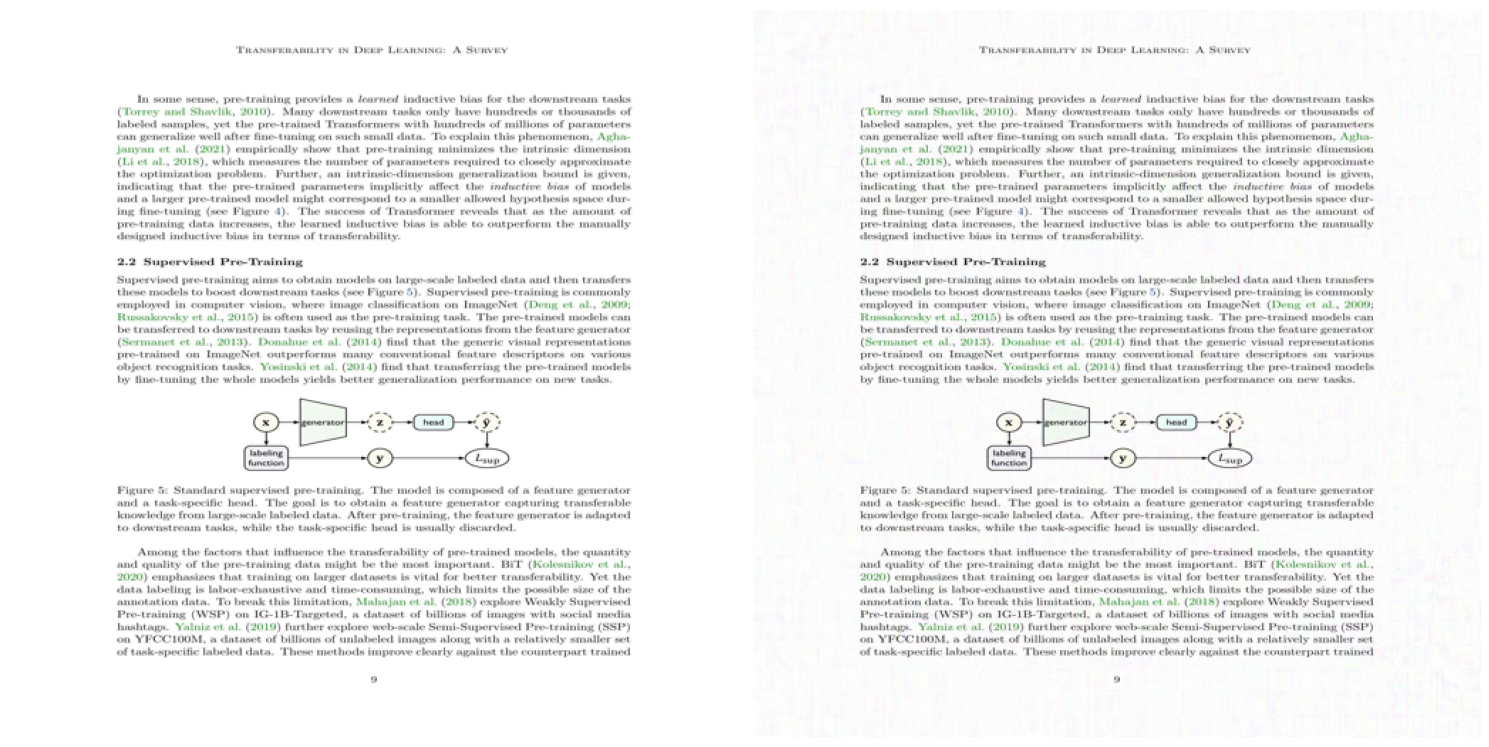

In [8]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [9]:
ds.add_adv_image(T.ToPILImage()(image_adv/255))

### Retrieve most relevant image for each query

In [10]:
if do_retrieval:
    embedded_ds = EmbeddedDataset(ds, embedder)
    embedded_ds.add_adv_image(T.ToPILImage()(image_adv/255))

    topks = [1,5]

    emb_test_loss_types_compatible = [loss for loss in emb_test_loss_types if is_loss_compatible(model_name_emb, loss)]
    metric_dict_before, retrievals_before = embedded_ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types_compatible, include_adv=False)
    print(f"Before attack: {metric_dict_before}")
    metric_dict_after, retrievals_after = embedded_ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types_compatible, include_adv=True)
    print(f"After attack: {metric_dict_after}")
    retrievals_train = {k: v["train"] for k,v in retrievals_after.items()}
    retrievals_test = {k: v["test"] for k,v in retrievals_after.items()}


Before attack: {'loss_maxsim_topk_1': {'acc': 0.12, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_maxsim_topk_5': {'acc': 0.39, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_1': {'acc': 0.06, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_5': {'acc': 0.18, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_softmaxsim_topk_1': {'acc': 0.06999999999999999, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_softmaxsim_topk_5': {'acc': 0.21000000000000002, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_cos_avgemb_topk_1': {'acc': 0.07999999999999999, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_cos_avgemb_topk_5': {'acc': 0.22, 'asr_train': 0.0, 'asr_test': 0.0}}
After attack: {'loss_maxsim_topk_1': {'acc': 0.11000000000000001, 'asr_train': 0.125, 'asr_test': 0.2}, 'loss_maxsim_topk_5': {'acc': 0.38, 'asr_train': 0.55, 'asr_test': 0.5}, 'loss_avgsim_topk_1': {'acc': 0.06, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_5': {'acc': 0.18, 'asr_train': 0.025, 'asr_test': 0.05}, 'loss_softmaxsim_topk_1

### Test Generation

In [12]:
if do_generation:
    # todo: fix this? delete this?
    gen_batch_size = 4
    metrics_test, gs_test = ds.evaluate_generation(
        vlm,
        image_adv,
        target_answer,
        metrics=["exact"],
        text_embedder=None,
        retrievals=retrievals_train,
        batch_size=gen_batch_size,
        generation_topk_list=[1],
        eval_train=False,
        print_gen=True,
    )
    print(f"Generation Test metrics: {metrics_test}")
    metrics_train, gs_train = ds.evaluate_generation(
        vlm,
        image_adv,
        target_answer,
        metrics=["exact"],
        text_embedder=None,
        retrievals=retrievals_test,
        generation_topk_list=[1],
        batch_size=gen_batch_size,
        eval_train=True,
    )
    print(f"Generation Train metrics: {metrics_train}")

100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


Generation Test metrics: defaultdict(<class 'dict'>, {'gen_topk_1': {'exact': 0.0}})


 25%|██▌       | 5/20 [00:02<00:08,  1.71it/s]


IndexError: list index out of range

In [ ]:
print_memory_consumption(device)

In [ ]:
ds.image_embeddings.shape

['I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!']
Evaluated 20 generations in 7.38s
Generation Test metrics: {'exact': 1.0}
Evaluated 80 generations in 24.48s
Generation Train metrics: {'exact': 1.0}


In [ ]:
print_memory_consumption(device)

Allocated RAM: 2.03 GB


In [ ]:
ds.image_embeddings.shape